# Geospatial clustering and temporal contagion of sexual violence the Colombian armed conflict: 1964 - 2024

In [1]:
# Core Data Manipulation and Utilities ----------------------------------------
library(dplyr)             # Data manipulation
library(janitor)           # Data cleaning utilities

# File I/O and Data Import/Export ---------------------------------------------- 
library(readxl)            # Read Excel files

# Visualisation and Reporting --------------------------------------------------
library(ggplot2)           # Advanced plotting (part of tidyverse but explicit)
library(patchwork)         # Combine multiple plots

# Geospatial Analysis ----------------------------------------------------------
# Basic spatial data handling
library(sf)                # Spatial data manipulation and analysis
library(rnaturalearth)     # Natural Earth map data
library(rnaturalearthdata) # Natural Earth map datasets

# Spatial Point Process Analysis
library(spatstat.geom)     # Spatial point pattern geometry
library(spatstat.linnet)   # Network-based spatial analysis
library(spatstat.explore)  # Pair correlation and Kest

library(terra)             # Spatial data analysis

# Hawkes Process Modelling and Log-Gaussian Cox Process (LGCP) Modelling
library(stelfi)            # Hawkes and log-Gaussian Cox process models

# Additional Log-Gaussian Cox Process (LGCP) Modelling
library(inlabru)           # LGCP model fitting and comparison
library(INLA)              # Integrated nested Laplace approximations
# Note: Install INLA with:
# install.packages("INLA", repos=c(getOption("repos"), 
#                  INLA="https://inla.r-inla-download.org/R/stable"), dep=TRUE)

# Open data on Colombia
library(ColOpenData)       # Colombia demographic, geospatial, and population data
library(colmaps)           # Maps of Colombia, available from https://github.com/nebulae-co/colmaps


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Linking to GEOS 3.13.1, GDAL 3.10.3, PROJ 9.6.0; sf_use_s2() is TRUE


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110


Loading required package: spatstat.data

Loading required package: spatstat.univar

spatstat.univar 3.1-4

spatstat.geom 3.6-0


Attaching package: ‘spatstat.geom’


The following object is masked from ‘package:patchwork’:

    area


Loading required package: spatstat.random

spatstat.random 3.4-2

Loading required package: spatstat.explore

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


spatstat.expl

In [2]:
# Set random seed for reproducibility
set.seed(7550822)

In [3]:
# Path to data files and output directory
data_path <- "/home/main/data/ColSVData/"
output_dir <- "/home/main/data/ColSVOutput/"

### Import conflict event data files

In [4]:

# Define the list of required columns
required_columns <- c("ID Caso", "Código DANE de Municipio", "Municipio", "Departamento", 
                      "Año", "Mes", "Día", "ID Persona", "Sexo", "Etnia", "Ocupación", 
                      "Calidad de la Víctima o la Baja", "Latitud", "Longitud", "Edad",
                      "Fuerza o Grupo Armado Organizado al que Pertenece el Combatiente", "Situación Actual de la Víctima", 
                      "Días de Cautiverio",  "No. de Veces secuestrado")

file_list <- list.files(path = data_path, pattern = "\\.xlsx$", full.names = TRUE)

# Exclude temporary files like ~$filename.xlsx
file_list <- file_list[!grepl("~\\$", basename(file_list))]

# Function to detect and convert data types
detect_and_convert_types <- function(df) {
  df_converted <- df
  
  for (col_name in names(df)) {
    col_data <- df[[col_name]]
    
    # Skip if all values are NA
    if (all(is.na(col_data))) {
      next
    }
    
    # Remove NA values for type detection
    non_na_values <- col_data[!is.na(col_data)]
    
    # Try to convert to numeric if it makes sense
    numeric_conversion <- suppressWarnings(as.numeric(non_na_values))
    
    # If conversion was successful for most values, treat as numeric
    if (sum(!is.na(numeric_conversion)) / length(non_na_values) > 0.8) {
      df_converted[[col_name]] <- suppressWarnings(as.numeric(col_data))
    } else {
      # Keep as character
      df_converted[[col_name]] <- as.character(col_data)
    }
  }
  
  return(df_converted)
}

data_list <- lapply(file_list, function(file) {
  # Read everything as text first to avoid type conflicts
  df <- read_excel(file, col_types = "text")
  
  # Automatically detect and convert data types
  df <- detect_and_convert_types(df)
  
  # Ensure required_columns is a character vector
  required_columns <- as.character(required_columns)
  
  # Ensure required columns exist
  missing_cols <- setdiff(required_columns, names(df))
  if (length(missing_cols) > 0) {
    df[missing_cols] <- NA
  }
  
  # Select only the required columns that exist
  df <- dplyr::select(df, intersect(names(df), required_columns))
  
  # Add file name as identifier
  df$Source_File <- basename(file)
  
  return(df)
})

### Data tidying

In [5]:
# Combine into single dataframe
combined_data <- bind_rows(data_list)

# Some data tidying
# Turns to snake_case, removes accents
combined_data <- janitor::clean_names(combined_data)  

# Replace all blank values with NA
combined_data[combined_data == ""] <- NA

# If columns are characters and might include blanks
combined_data <- combined_data %>%
  mutate(across(c(ano, mes, dia), ~ ifelse(. == 0 | . == "" | is.na(.), NA, .)))

# Ensure the columns are numeric
combined_data$ano <- as.numeric(combined_data$ano)
combined_data$mes <- as.numeric(combined_data$mes)
combined_data$dia <- as.numeric(combined_data$dia)

# Remove rows with any missing date parts
combined_data <- combined_data[complete.cases(combined_data[, c("ano", "mes", "dia")]), ]

# Combine year, month, day into a string
combined_data$DateString <- paste(combined_data$ano,
                                  sprintf("%02d", combined_data$mes),
                                  sprintf("%02d", combined_data$dia),
                                  sep = "-")

# Convert to POSIXct
combined_data$Date <- as.POSIXct(combined_data$DateString, format = "%Y-%m-%d", tz = "UTC")

# Recode violence event types
combined_data <- combined_data %>%
  dplyr::mutate(EventType = case_when(
    source_file == "VictimasAB_202409.xlsx" ~ "AB", # Acciones Bélicas
    source_file == "VictimasAP_202409.xlsx" ~ "AP", # Ataques Poblaciones
    source_file == "VictimasAS_202409.xlsx" ~ "AS", # Asesinatos selectivos
    source_file == "VictimasAT_202409.xlsx" ~ "AT", # Atentados Terroristas
    source_file == "VictimasDB_202409.xlsx" ~ "DB", # Daños a bienes civiles
    source_file == "VictimasDF_202409.xlsx" ~ "DF", # Desaparición forzada
    source_file == "VictimasMA_202409.xlsx" ~ "MA", # Masacres
    source_file == "VictimasMI_202409.xlsx" ~ "MI", # Minas
    source_file == "VictimasRU_202409.xlsx" ~ "RU", # Reclutamiento y utilización de niños, niñas y adolescentes
    source_file == "VictimasSE_202409.xlsx" ~ "SE", # Secuestos
    source_file == "VictimasVS_202409.xlsx" ~ "VS", # Violencia sexual
    TRUE ~ NA_character_  # default case if no match
  ))

combined_data$EventType <- as.factor(combined_data$EventType)

# Convert to numeric time (e.g., for some Hawkes models)
combined_data$Timestamp <- as.numeric(combined_data$Date)

# Convert to spatial point pattern (longitude & latitude as spatial features)

# Define observation window (bounding box for spatial analysis)
W <- owin(xrange = c(min(combined_data$longitud), max(combined_data$longitud)), 
          yrange = c(min(combined_data$latitud), max(combined_data$latitud)))

# Convert time dimension to relative time units
combined_data$Time <- as.numeric(difftime(combined_data$Timestamp, min(combined_data$Timestamp), units="days"))

# Remove missing timepoints
combined_data <- combined_data[!is.na(combined_data$Timestamp), ]

# Sort the data by time:
combined_data <- combined_data[order(combined_data$Timestamp), ]

#Convert to numeric relative time (in days or seconds):
combined_data$t <- as.numeric(difftime(combined_data$Timestamp, min(combined_data$Timestamp), units = "days"))
combined_data <- combined_data[order(combined_data$t), ]
combined_data$x <- combined_data$longitud
combined_data$y <- combined_data$latitud

# Convert data frame to an sf object
combined_data_sf <- st_as_sf(combined_data, coords = c("longitud", "latitud"), crs = 4326)

# Set the CRS to the desired one
st_crs(combined_data_sf) <- "+proj=longlat +datum=WGS84 +no_defs +ellps=WGS84 +towgs84=0,0,0"

# Filter out rows where coordinates are 0
combined_data_sf <- combined_data_sf %>%
  filter(st_coordinates(geometry)[,1] != 0 & st_coordinates(geometry)[,2] != 0)

# Filter out rows with non-finite Date values
combined_data_sf <- combined_data_sf %>%
  filter(!is.na(Date))

# Ensure the variable is in Date format
combined_data_sf$DateString <- as.Date(combined_data_sf$DateString)

# Extract the year from the date
combined_data_sf$Year <- format(combined_data_sf$DateString, "%Y")

# Convert year to numeric
combined_data_sf$Year <- as.numeric(combined_data_sf$Year)

# Filter for dates from 1964-05-27 onwards
combined_data_sf_entire_conflict <- combined_data_sf %>%
  filter(DateString >= as.Date("1964-05-27"))

# Only keep sexual violence events
SV_combined_data_sf_entire_conflict <- combined_data_sf_entire_conflict %>%
  filter(EventType == "VS")

In [6]:
# Set image size
options(repr.plot.width=5, repr.plot.height=5, repr.plot.res = 210)

Data preparation

In [7]:
# Get the map of Colombia as an sf object
colombia <- ne_countries(country = "Colombia", returnclass = "sf") %>%
  sf::st_make_valid()

# dataframe of sighting locations (lat, long)
locs <- sf::st_coordinates(SV_combined_data_sf_entire_conflict) %>%
  as.data.frame() %>%
  rename(., c("x" = "X", "y" = "Y"))

# Filter out datapoints in San Andres and Providencia
locs <- locs %>%
  filter(!(x < -80 & y > 11 & y < 14.5))  # Remove points in that box
  
# Delauney triangluation of domain
smesh <- INLA::inla.mesh.2d(loc = locs[, 1:2], max.edge = 1, cutoff = 1)

#### Get and process population density data

In [8]:
# Define file name and location
pop_file <- paste(data_path, "municipios_pop_1985-2024.csv", sep = "")

# Check if file exists, if not download and save
if (!file.exists(pop_file)) {
  municipios_pop <- download_pop_projections("municipality", 1985, 2024)
  
  # Fix errors in the fetched data from orginal source!
  # 1985 - 2014 codigo_municipio column is labelled correctly, municipio column is labelled correctly
  # 2005 - 2019 codigo_municipio column and municipio column have been mislabelled. the labels have been swapped
  # 2020 onwards codigo_municipio column is labelled correctly, municipio column is labelled correctly
  municipios_pop <- municipios_pop %>%
    mutate(
      codigo_municipio = ifelse(ano >= 2005 & ano <= 2019, municipio, codigo_municipio),
      municipio = ifelse(ano >= 2005 & ano <= 2019, codigo_municipio, municipio)
    )
  
  write.csv(municipios_pop, pop_file, row.names = FALSE)
}

# Load population data
municipios_pop <- read.csv(pop_file, 
                           colClasses = c(codigo_municipio = "character"))

# Filter for total population (data file has separate entries for rural, urban and total within each municipio)
# and for the correct year range (1985-2024 - the only data range available) for the analysis
municipios_pop <- municipios_pop %>%
  filter(area == "total") %>%
  filter(between(ano, 1985, 2024))


#### Convert municipio population density into covariate matrix 

In [9]:
# Calculate average population by municipality
avg_population <- municipios_pop %>%
  group_by(codigo_municipio) %>%
  summarise(avg_population = mean(total, na.rm = TRUE))

# Get municipality spatial data
municipios_sp <- colmaps::municipios
municipios <- st_as_sf(municipios_sp)

# Ensure codigo_municipio is character for proper joining
municipios$codigo_municipio <- as.character(municipios$id)

# Join population data
municipios <- municipios %>%
  dplyr::left_join(avg_population, by = "codigo_municipio")

# Calculate area and population density
municipios$area_km2 <- as.numeric(st_area(municipios)) / 1e6
municipios$pop_density <- municipios$avg_population / municipios$area_km2

# Handle NA and infinite values
municipios$pop_density[is.na(municipios$pop_density) | is.infinite(municipios$pop_density)] <- 1e-6

# Ensure CRS consistency (WGS84 / EPSG:4326)
municipios <- st_transform(municipios, crs = 4326)

# Create raster template with proper CRS
bbox <- st_bbox(municipios)
raster_template <- rast(xmin = bbox["xmin"], xmax = bbox["xmax"],
                        ymin = bbox["ymin"], ymax = bbox["ymax"],
                        resolution = 0.01, crs = "EPSG:4326")

# Convert to terra vector for rasterization
municipios_vect <- vect(municipios)

# Rasterize population density
pop_density_raster <- rasterize(municipios_vect, raster_template, 
                                field = "pop_density", fun = "mean")

# Log-transform population density (recommended for skewed distributions)
# Add small constant to avoid log(0)
pop_density_raster_log <- log(pop_density_raster + 1e-6)

# Convert raster to matrix for fit_lgcp
# The covariate matrix should match the mesh structure
pop_density_matrix <- as.matrix(pop_density_raster_log, wide = TRUE)

# Alternative: Extract values at mesh node locations
mesh_coords <- smesh$loc[, 1:2]  # Get mesh node coordinates
mesh_coords_sf <- st_as_sf(as.data.frame(mesh_coords), 
                           coords = c("V1", "V2"), 
                           crs = 4326)

# Extract population density values at mesh nodes
pop_density_at_nodes <- st_join(mesh_coords_sf, 
                                municipios %>% dplyr::select(pop_density), 
                                join = st_intersects)

# Create covariate matrix (one column for pop density)
covariate_matrix <- matrix(log(pop_density_at_nodes$pop_density + 1e-6), 
                           ncol = 1)

# Handle any remaining NA values
covariate_matrix[is.na(covariate_matrix)] <- mean(covariate_matrix, na.rm = TRUE)

Fit LGCP Model as in our main analysis

,Estimate,Std. Error
beta,2.0324397,0.3693167
beta,0.5299729,0.0877647
log_tau,-2.3337069,0.1212918
log_kappa,0.4900827,0.1605215
range,1.7326258,0.2781238
stdev,1.7826697,0.1522646


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


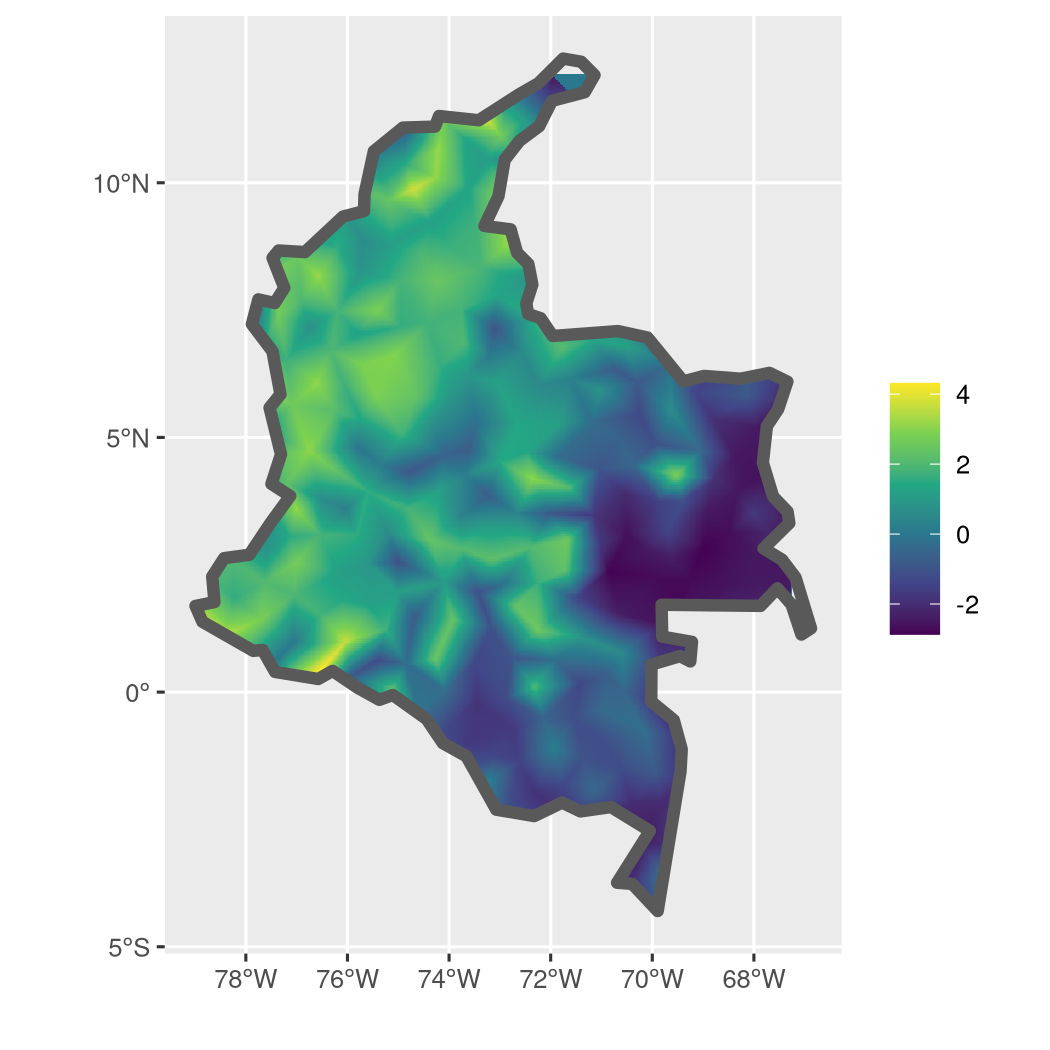

In [10]:
fit_spatial <- fit_lgcp(locs = locs, 
                        sf = colombia, 
                        smesh = smesh,
                        covariates = covariate_matrix,
                        parameters = list(beta = c(0, 0),  
                                          log_tau = log(1),
                                          log_kappa = log(1)))

get_coefs(fit_spatial)

## estimate random field
get_fields(fit_spatial, smesh) |>
    show_field(smesh = smesh, sf = colombia, clip = TRUE)

In [11]:
## now using UTMs rather than longitude and latitude
points <- SV_combined_data_sf_entire_conflict

## downloaded 2020 population tif, for greater resolution
## need to update to include all yearly data
## source https://hub.worldpop.org/geodata/summary?id=40675
pop_raster <- terra::rast(paste(data_path, "col_pd_2020_1km.tif", sep=""))
utm_epsg <- 32618
points_utm <- st_transform(points, crs = utm_epsg)
colombia_utm <- st_transform(colombia, crs = utm_epsg)

## keep points inside
## inside <- sf::st_within(points_utm, colombia_utm, sparse = FALSE)
## points_utm <- points_utm[rowSums(inside) > 0, ]
pop_raster_utm <- terra::project(pop_raster, terra::crs(points_utm))

## very course for illustration only
locs <- sf::st_coordinates(points_utm) |> as.data.frame(); names(locs) <- c("x", "y")
smesh <- fmesher::fm_mesh_2d_inla(boundary = colombia_utm,locs = locs,
                                  max.edge = c(50000, 150000), cutoff = 60000)
smesh$crs <- st_crs(points_utm)

## new population covariate
mesh_sf <- sf::st_as_sf(
   data.frame(x = smesh$loc[,1], y = smesh$loc[,2]),
   coords = c("x","y"),
   crs = st_crs(pop_raster_utm)
 )

## Extract raster population density at mesh nodes, note only 2020
## for now
covariate_matrix <-  terra::extract(pop_raster_utm, mesh_sf)[,2] |> as.matrix()
colnames(covariate_matrix) <- "population_density"
covariate_matrix[is.na(covariate_matrix[,1]), 1] <- 1e-6

Warning message in stats::nlminb(obj$par, obj$fn, obj$gr, control = list(trace = trace), :
“NA/NaN function evaluation”
Warning message in stats::nlminb(obj$par, obj$fn, obj$gr, control = list(trace = trace), :
“NA/NaN function evaluation”


,Estimate,Std. Error
beta,-2.082954e+01,6.587987e-01
beta,-6.807785e-04,6.593911e-04
log_tau,9.330530e+00,8.698220e-02
log_kappa,-1.155067e+01,1.400990e-01
range,2.937236e+05,4.115038e+04
stdev,2.597712e+00,2.722840e-01


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


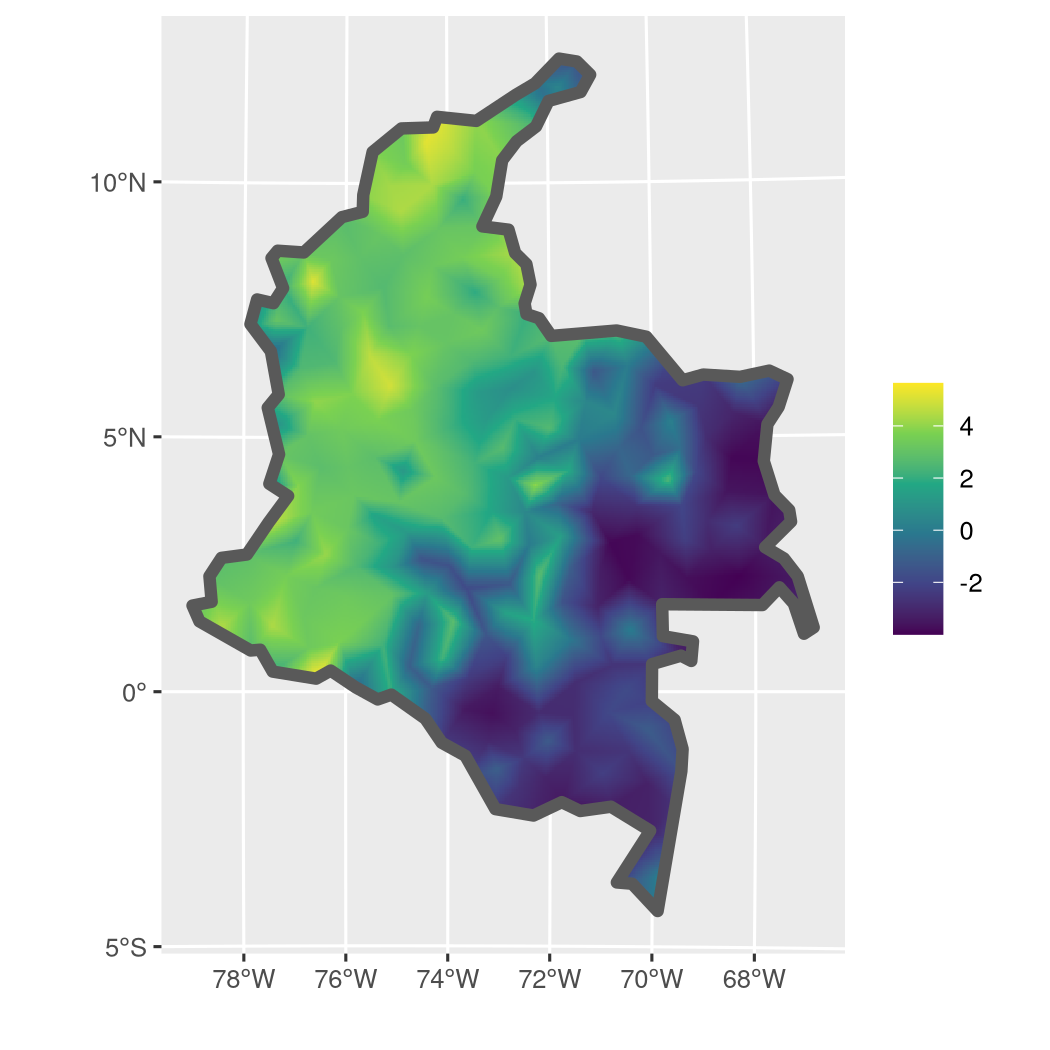

In [12]:
## Spatial only model using UTMs and 2020 
fit_spatial_02 <- fit_lgcp(locs = locs, 
                        sf = colombia_utm, 
                        smesh = smesh,
                        covariates = covariate_matrix,
                        parameters = list(beta = c(0, 0),  
                                          log_tau = log(1),
                                          log_kappa = log(1)))
get_coefs(fit_spatial_02)
get_fields(fit_spatial_02, smesh) |>
    show_field(smesh = smesh, sf = colombia_utm, clip = TRUE)


In [13]:
## likelihood
fit_spatial_02$objective

[1] 1019.003

Warning message in bru_log_warn(msg):
“Model input 'pop_raster_utm' for 'population_density' returned some NA values.
Attempting to fill in spatially by nearest available value.
To avoid this basic covariate imputation, supply complete data.”



 *** inla.core.safe:  The inla program failed, but will rerun in case better initial values may help. try=1/1 

 *** inla.core.safe:  rerun with improved initial values 


,mean,sd,0.025quant,0.5quant,0.975quant,mode,kld
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Intercept,-3.33684486,4.390673e-05,-3.33693092,-3.33684486,-3.33675880,-3.33684486,0
population_density,-0.02609949,1.349135e-06,-0.02610214,-0.02609949,-0.02609685,-0.02609949,0


,mean,sd,0.025quant,0.5quant,0.975quant,mode
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Range for spatial,1.013924e+06,2.342633e+03,1.010706e+06,1.013554e+06,1.019458e+06,1.011897e+06
Stdev for spatial,1.469910e+00,5.485683e-03,1.462381e+00,1.469040e+00,1.482879e+00,1.465158e+00


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


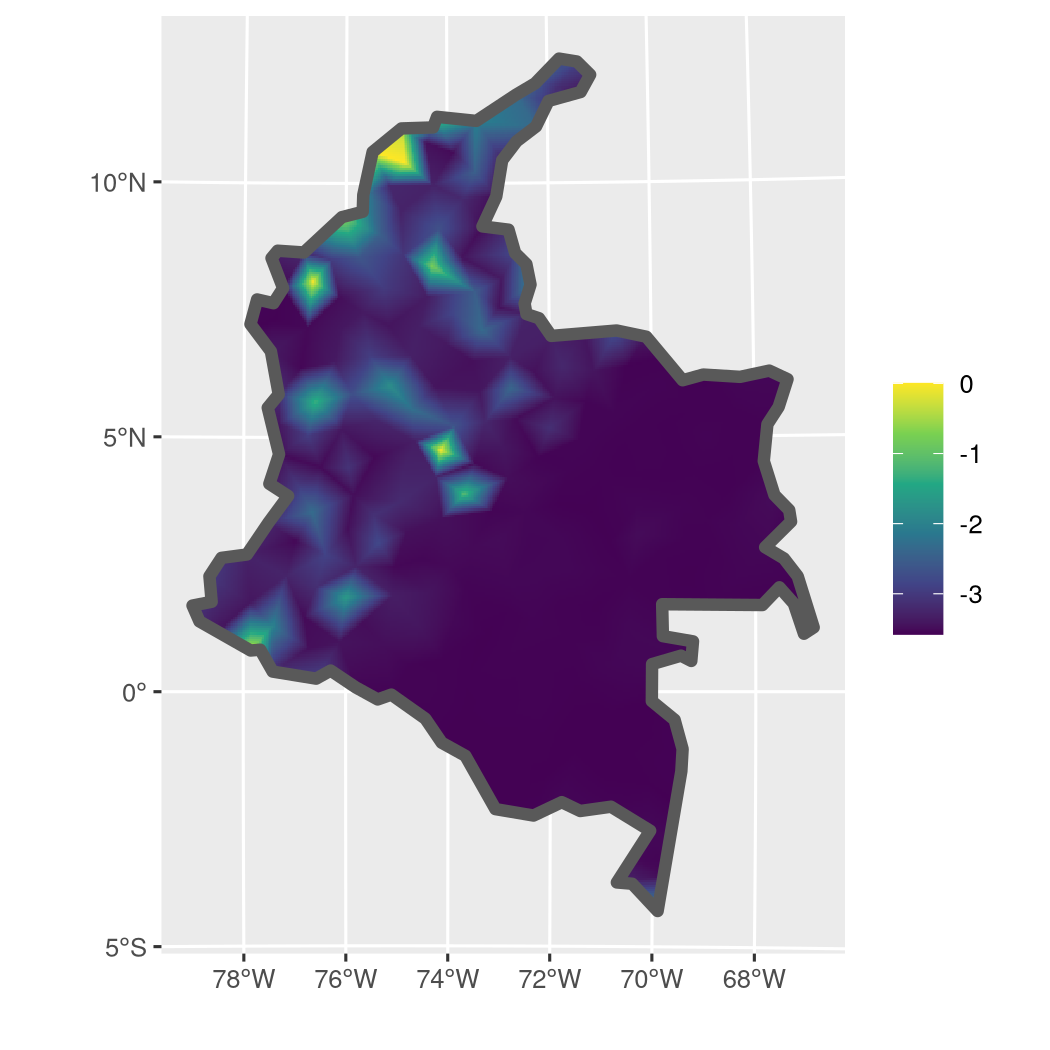

In [14]:
## for hyperpar priors
diameter <- as.numeric(
  st_length(st_cast(st_convex_hull(colombia_utm), "MULTILINESTRING"))
)

## SPDE
spde <- inla.spde2.pcmatern(
  mesh = smesh,
  prior.range = c(diameter/3, 0.5),  
  prior.sigma = c(1, 0.01))

## linear predictor
components <- geometry  ~ Intercept(1) + population_density(pop_raster_utm) +
  spatial(geometry, model = spde)

fit <- lgcp(components, points_utm,
            samplers = colombia_utm,
            domain = list(geometry = smesh),
            options = list(control.inla = list(int.strategy = "eb"))
)

fit$summary.fixed
fit$summary.hyperpar

## field
show_field(fit$summary.random$spatial$mean, smesh = smesh, sf = colombia_utm, clip = TRUE)

In [15]:
## simulate from GMRFs

field_to_im <- function(x, smesh, sf, dims = c(500,500)){
    nx <- dims[1]
    ny <- dims[2]
    xs <- seq(min(smesh$loc[, 1]), max(smesh$loc[, 1]), length = nx)
    ys <- seq(min(smesh$loc[, 2]), max(smesh$loc[, 2]), length = ny)
    data <- expand.grid(xs = xs, ys = ys)
    pxl <- sf::st_multipoint(as.matrix(data))
    A <- fmesher::fm_basis(smesh, pxl)
    data$colz <-  as.vector(A %*% x)
    xy <- sf::st_as_sf(data, coords = c("xs", "ys"))
    sf::st_crs(xy) <- sf::st_crs(sf)
    idx <- lengths(sf::st_intersects(xy, sf)) > 0
    data[!idx, ] <- 0
    z_grid <- matrix(data$colz, nrow = ny, ncol = nx, byrow = TRUE)
    im_obj <- im(z_grid, xcol = xs, yrow = ys)
    return(im_obj)
}

## inlabru - sim 
image <- field_to_im(x = exp(fit$summary.random$spatial$mean - 3.3), smesh = smesh, sf = colombia_utm)
pixel_area <- (diff(range(image$xcol)) / (length(image$xcol)-1)) *
              (diff(range(image$yrow)) / (length(image$yrow)-1))

## scale intensity 
total_expected <- nrow(points_utm) 
image$v <- image$v / sum(image$v) * total_expected / pixel_area

In [16]:
# Set image size
options(repr.plot.width=5, repr.plot.height=5, repr.plot.res = 210)

In [17]:
## simulate from random field, no population effect
pp_sims <- spatstat.random::rpoispp(image, nsim = 100)

Kobs <- Kest(as.ppp(points_utm))
Ksim <- lapply(pp_sims, function(x) Kest(as.ppp(x)))

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - computing border correction estimate only

number of data points exceeds 3000 - com

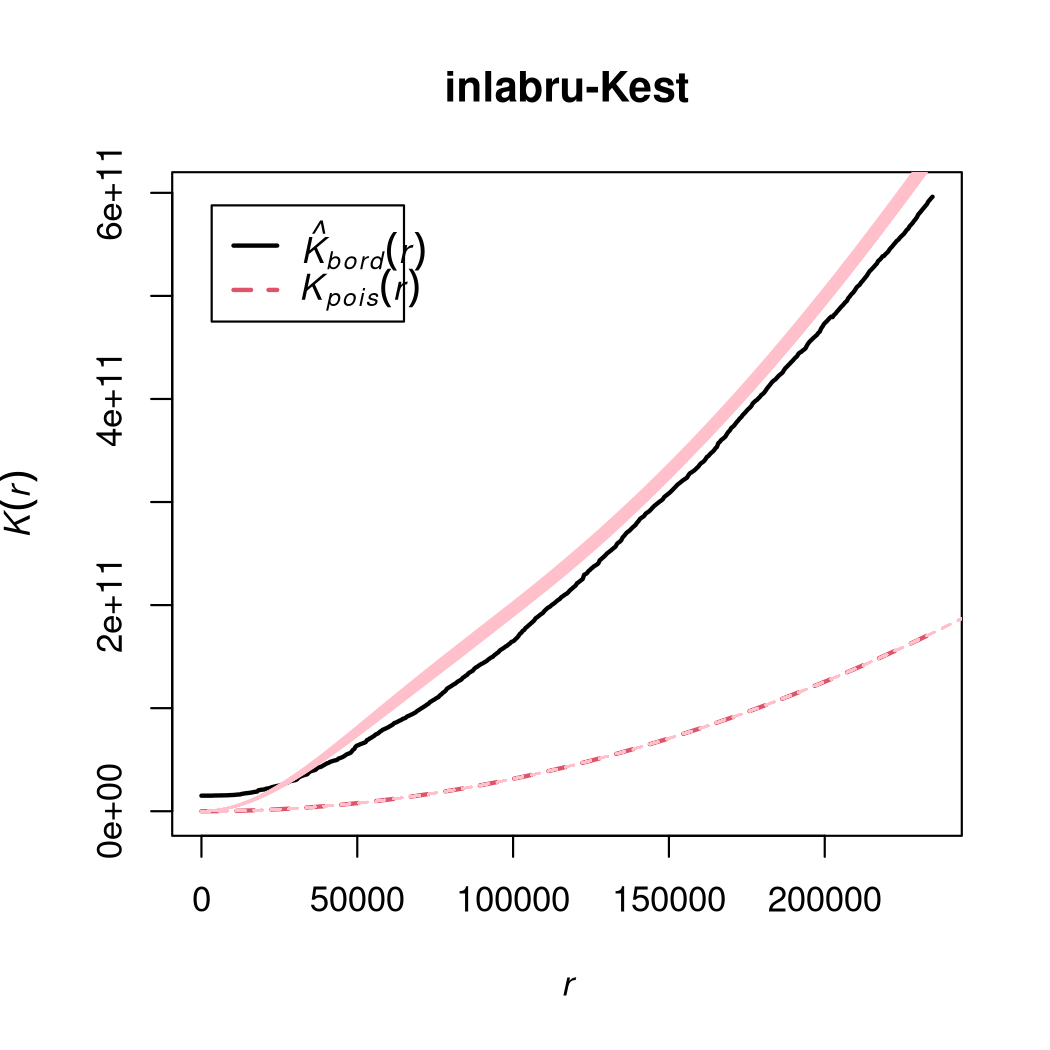

In [18]:
plot(Kobs, lwd = 2, main = "inlabru-Kest")
invisible(lapply(Ksim, plot, col = "pink", add = TRUE))

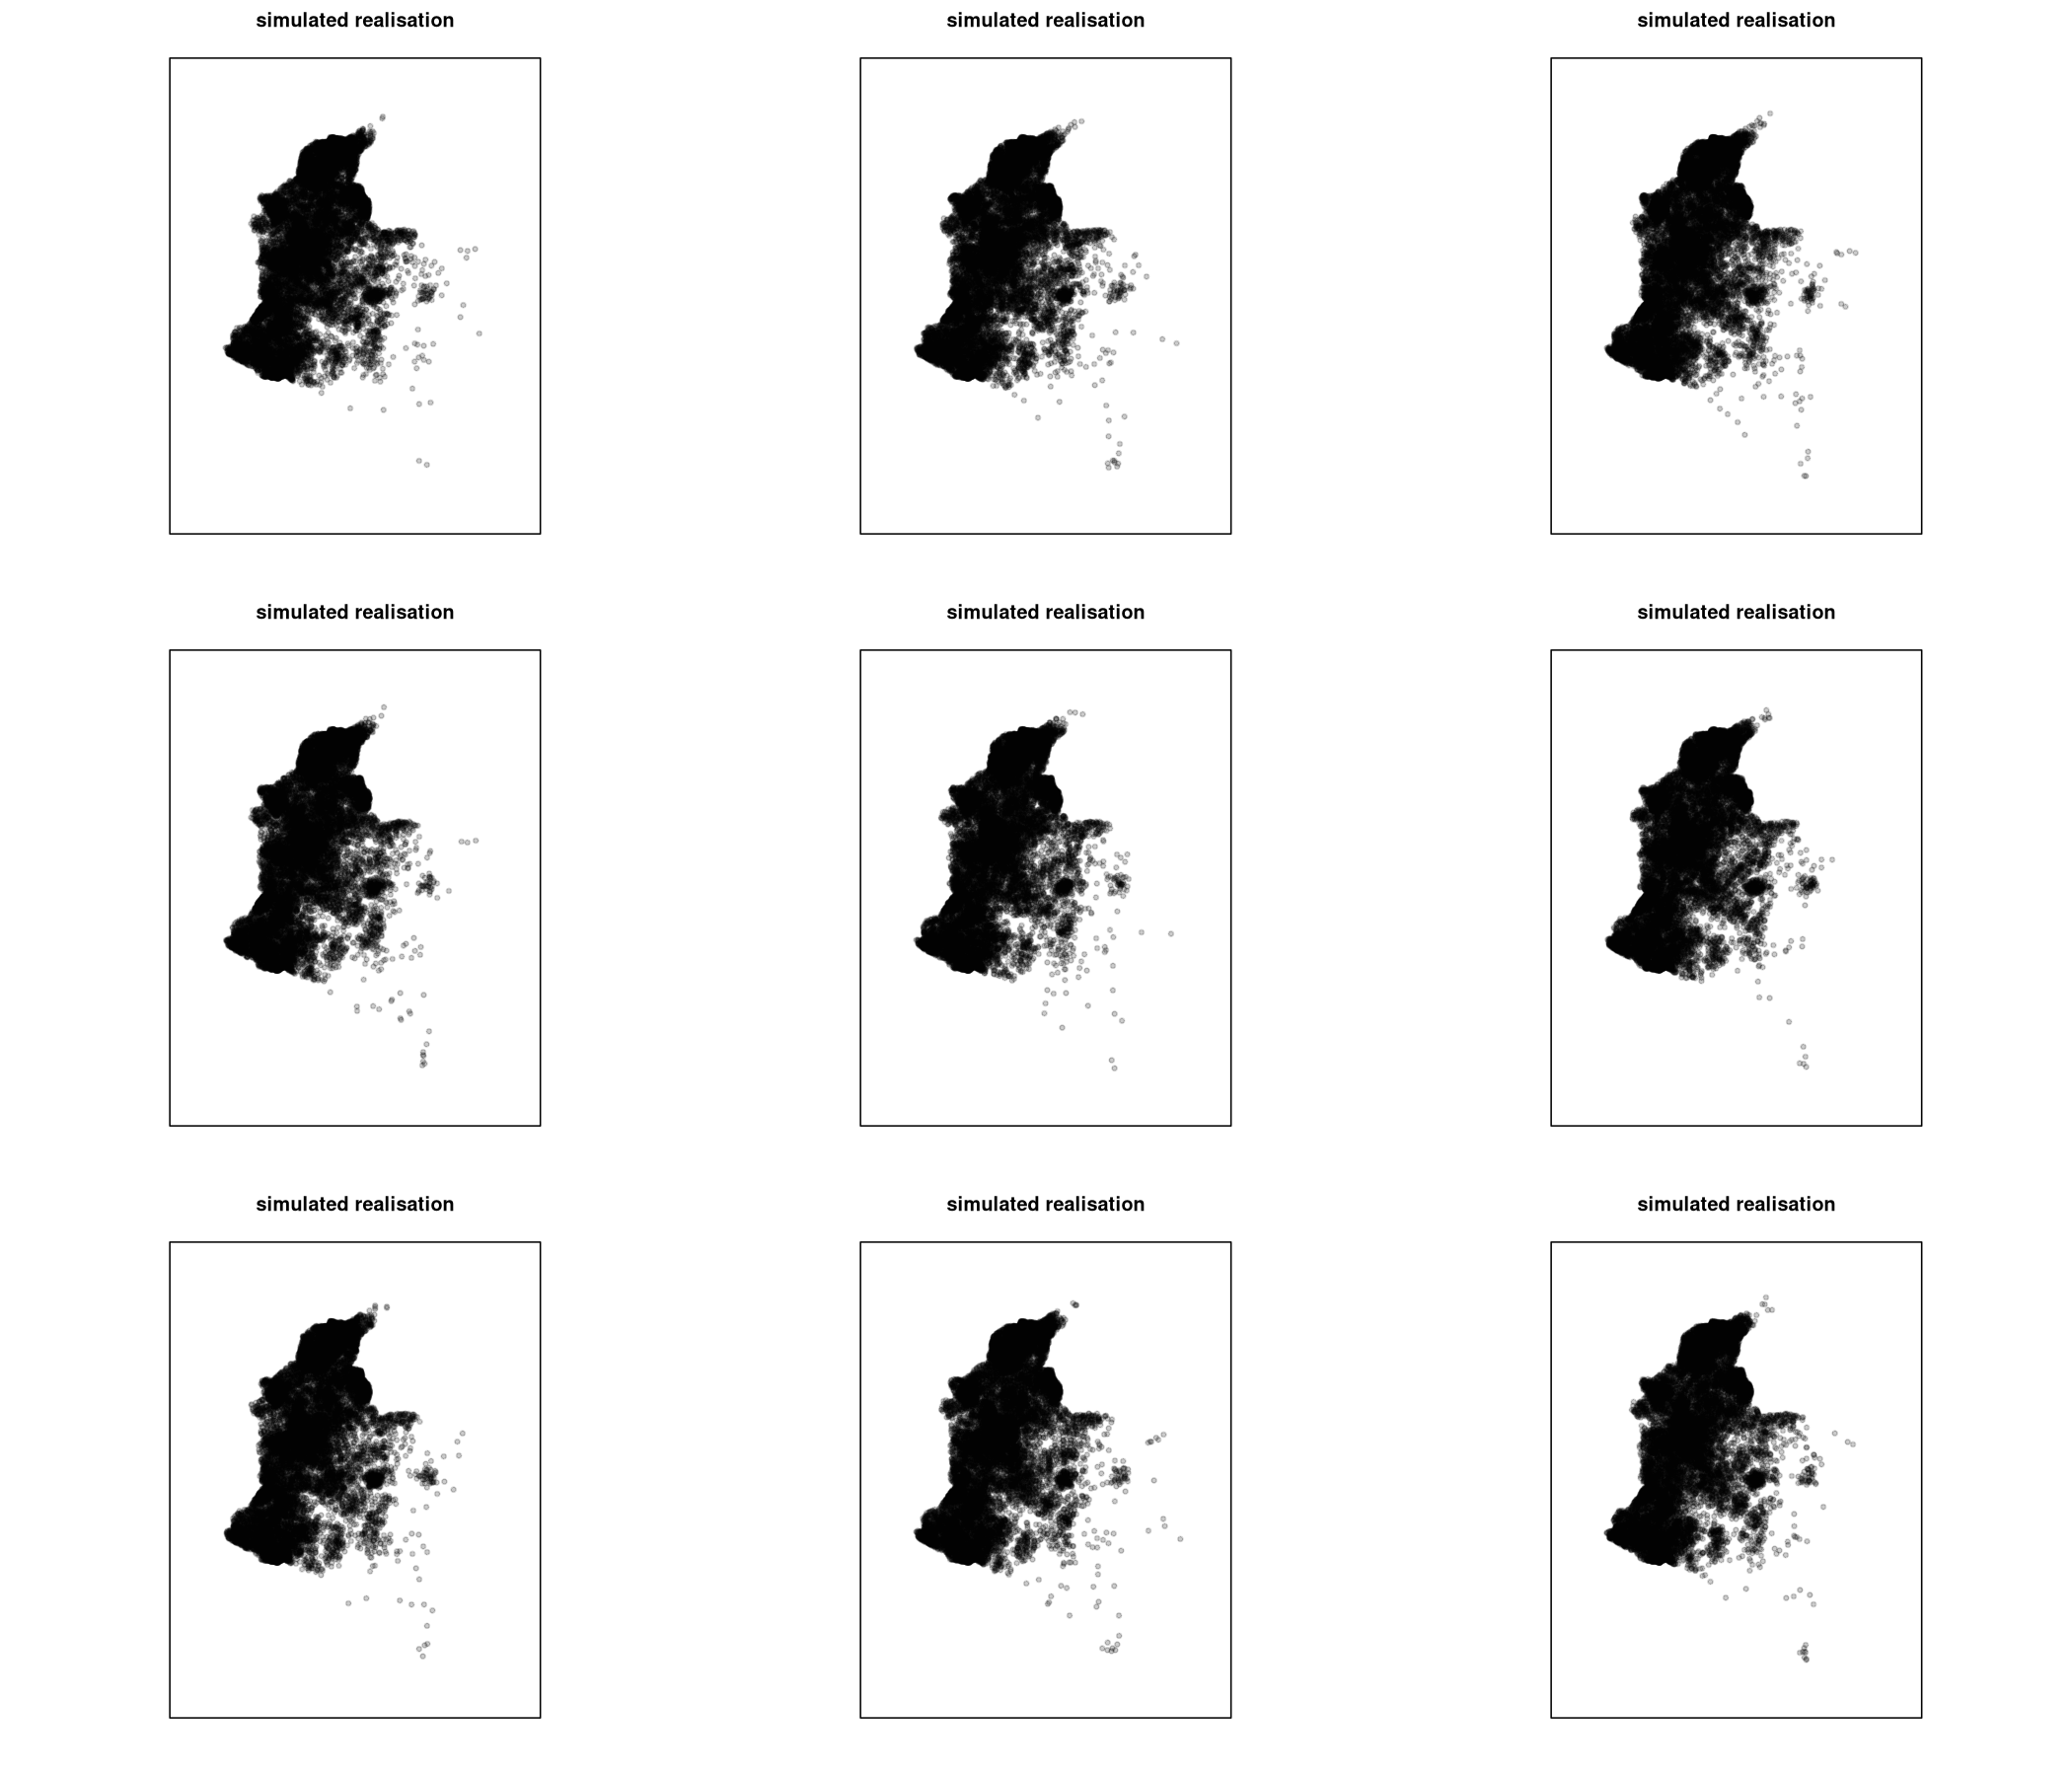

In [19]:
## stelfi
## fitted intensity
get_lambda <- function(obj, covariates){
    designmat <- cbind(1, covariates)
    res <- TMB::sdreport(obj)
    field <- res$par.random
    beta <- res$value["beta" == names(res$value)]
    beta <- as.matrix(beta, ncol = 1)
    lambda <- exp(field + designmat%*%beta)
    return(lambda)
}

image <- field_to_im(x = get_lambda(fit_spatial_02, covariate_matrix), smesh = smesh, sf = colombia_utm)

## Simulate 9 realisations from the fitted intensity (including field)
# Set up 3x3 grid
options(repr.plot.width=14, repr.plot.height=12, repr.plot.res = 150)
par(mfrow = c(3, 3), mar = c(2, 2, 2, 1))

# Plot
pp_sims <- spatstat.random::rpoispp(image, nsim = 9)
invisible(lapply(pp_sims, plot, pch = 20, main = "simulated realisation"))

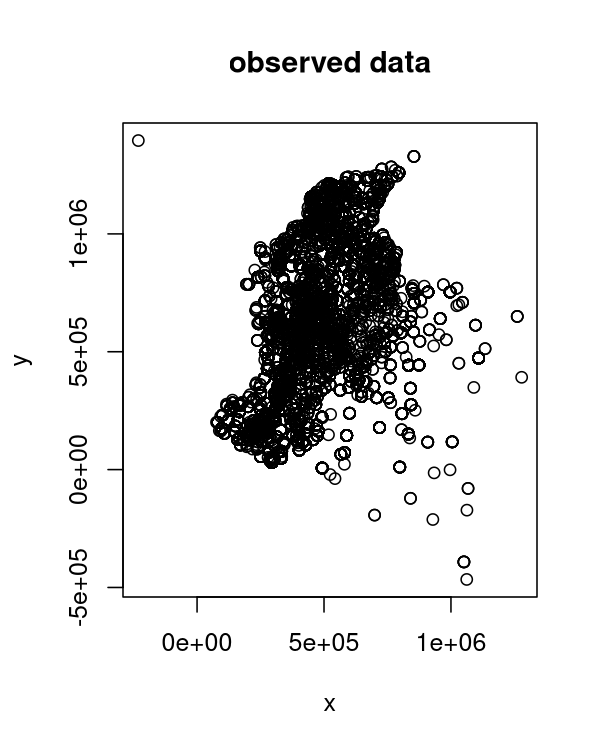

In [20]:
# Plot observed data
options(repr.plot.width=4, repr.plot.height=5, repr.plot.res = 150)
plot(locs, main = "observed data")

### Show version of R and versions of packages used in this analysis

In [21]:
r_version <- R.version

# Format and print the R version details
cat(paste("R version:", r_version$version.string), "\n")
cat(paste("Platform:", r_version$platform), "\n")

R version: R version 4.5.0 (2025-04-11) 
Platform: x86_64-pc-linux-gnu 


In [22]:
loaded_packages <- c("dplyr", "janitor", 
                     "readxl", 
                     "ggplot2", "patchwork", 
                     "sf", "rnaturalearth", "rnaturalearthdata", 
                     "spatstat.geom", "spatstat.linnet", "spatstat.explore", "terra",
                     "hawkes", "stelfi", 
                     "inlabru", "INLA",
                     "ColOpenData", "colmaps")
                     
# Print package names and versions for the specified packages
for (pkg in loaded_packages) {
    version <- packageVersion(pkg)
    cat(paste(pkg, " version: ", version, sep = ""), "\n")
}

dplyr version: 1.1.4 
janitor version: 2.2.1 
readxl version: 1.4.5 
ggplot2 version: 4.0.0 
patchwork version: 1.3.2 
sf version: 1.0.21 
rnaturalearth version: 1.1.0 
rnaturalearthdata version: 1.0.0 
spatstat.geom version: 3.6.0 
spatstat.linnet version: 3.3.2 
spatstat.explore version: 3.5.3 
terra version: 1.8.70 
hawkes version: 0.0.4 
stelfi version: 1.0.2 
inlabru version: 2.13.0 
INLA version: 25.6.7 
ColOpenData version: 1.0.0 
colmaps version: 0.0.0.9515 
